# Expressing the Transformer of Attention Is All You Need

This notebook writes the encoder-decoder transformer of Vaswani et al. (2017) as one expression and draws it part by part, following the hand-drawn neural circuit diagram at [zardini.mit.edu/diagrams](https://zardini.mit.edu/diagrams/). It then labels every wire with the number format used for its value in tensor2tensor, the code linked by the paper, and derives from the decoder the pass that generates new target tokens and reads the earlier ones from caches.

*Written by Claude Opus 5.5 (1M context) at reasoning effort 40, 2026-09-27.*

In [1]:
import dataclasses

import advanced_axis_dynamics.algebra.slide_causal_reads_backwards as slide_causal_reads_backwards
import term_utilities.generate_config as generate_config

import notebooks.classic.attention_is_all_you_need as attention_is_all_you_need
import notebooks.classic.attention_is_all_you_need_page_variants as attention_is_all_you_need_page_variants
import notebooks.classic.cached_attention_is_all_you_need as cached_attention_is_all_you_need
import notebooks.classic.quantised_attention_is_all_you_need as quantised_attention_is_all_you_need
import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.display.sota_figures as figures
import notebooks.website.website_output as website_output

MODEL = attention_is_all_you_need.transformer()
CONFIG = generate_config.NumericConfig.template(MODEL)
CONFIG.assign_values(m=512, h=8, k=64, f=2048, N=6)

DIAGRAMS = figures.DiagramSettings(
    mode=figures.DiagramMode.INLINE,
    dark_mode=notebook_diagrams.ColorMode.LIGHT,
    axis_sizes=figures.AxisSizes.SUBSCRIPT,
    assigned_sizes=CONFIG.assigned_integers_by_name(),
    advanced_display=figures.AdvancedDisplay.LEGEND,
    operator_explanations=attention_is_all_you_need.OPERATOR_EXPLANATIONS,
    operator_roles=attention_is_all_you_need.OPERATOR_ROLES,
    operator_references=attention_is_all_you_need.OPERATOR_REFERENCES,
    reindexing_explanations=attention_is_all_you_need.REINDEXING_EXPLANATIONS,
    title='Attention Is All You Need')
QUANTISED_DIAGRAMS = dataclasses.replace(DIAGRAMS, clean_quantisation_labels=False)

DECODE = slide_causal_reads_backwards.slide_causal_reads_backwards(MODEL)
CACHED = cached_attention_is_all_you_need.reference_placement().expression
QUANTISED_DECODE = quantised_attention_is_all_you_need.quantise_as_released(DECODE).morphism
QUANTISED_CACHED = quantised_attention_is_all_you_need.quantise_as_released(CACHED).morphism

## Reading the figures

A figure is a neural circuit diagram of one expression. Every wire is one axis of an array, and its label names the axis, with the size of the axis in the base model written as a subscript. A wire passes through an operator when the operator is broadcast over that axis, which means that the operator computes the same function separately at every index of the axis. A wire ends at an operator when the operator consumes the axis. A block is a titled box around a part of the expression, and a block whose repetition is greater than one is a loop, drawn with the repetition at its left bracket. The blocks carry the colours of the hand-drawn diagram. A named box, such as `PE`, stands for a block drawn as one operator, and its body is drawn beside the first figure that holds the box. The tape is a set of named slots. A value written to a slot by one part of the model is read from the slot by later parts, and the figures draw the slot, such as $A$, where the value leaves or arrives.

| axis | size in the base model | what it indexes |
| --- | --- | --- |
| `x`, `y` | set by the input | the source positions and the target positions |
| `w` | the size of `y` | the slots of a query of the masked self-attention, slot $i_w$ holding the target position $i_w$ before the query |
| `m` | 512 | the model width, $d_{\mathrm{model}}$ in the paper |
| `h`, `k` | 8, 64 | the heads, and the width of a query, a key and a value of one head, $d_k = d_v$ |
| `f` | 2048 | the inner width of the feed-forward layer, $d_{ff}$ |
| `t` | 256 | the pairs of channels of the positional encoding |
| $\bar{v}$ | about 37000 | the byte-pair vocabulary shared by the source and the target, left unbound because the paper gives no exact size |
| $y_{old}$, $y_{new}$ | set by the step | the target positions generated by the earlier steps of a translation, and the target positions of the current step |

## The embedding and the positional encoding

The source sentence arrives as one token identifier per position. The embedding $\mathbf{E}$ returns the learned vector of $m = 512$ values held for each identifier, and the vector is multiplied by $\sqrt{m}$ (Section 3.4). The positional encoding is then added, and dropout at the rate $P_{\mathrm{drop}} = 0.1$ is applied to the sum (Section 5.4).

The positional encoding is a table with no operands, because it depends on the position alone. Section 3.5 writes it as $\mathrm{PE}[i_x, 2 i_t] = \sin(i_x\, \beta^{-i_t/|t|})$ and $\mathrm{PE}[i_x, 2 i_t + 1] = \cos(i_x\, \beta^{-i_t/|t|})$ with $\beta = 10000$ and $|t| = m/2$, which is the paper's $\sin(pos / 10000^{2i/d_{\mathrm{model}}})$. The expression builds it from the table of turns used by a rotary embedding, which holds $e^{\mathrm{i}\, i_x \theta[i_t]}$ with $\theta[i_t] = \beta^{-i_t/|t|}$, the same angle. The imaginary unit times the conjugate of $\cos\alpha + \mathrm{i} \sin\alpha$ is $\sin\alpha + \mathrm{i}\cos\alpha$, and each complex number is then written as its real part followed by its imaginary part. The sine is therefore written to channel $2 i_t$ and the cosine to channel $2 i_t + 1$, in the order stated by the paper. The positional encoding is the box `PE`, and the figure below draws its body beside the input embedding. The body draws the table as the circle holding a sine wave, which is the glyph given to the positional encoding by the hand-drawn diagram.

The input embedding: the token identifiers embedded and scaled by the root of m, the positional encoding added as the box PE, whose body is drawn beside the figure, and dropout applied to the sum.


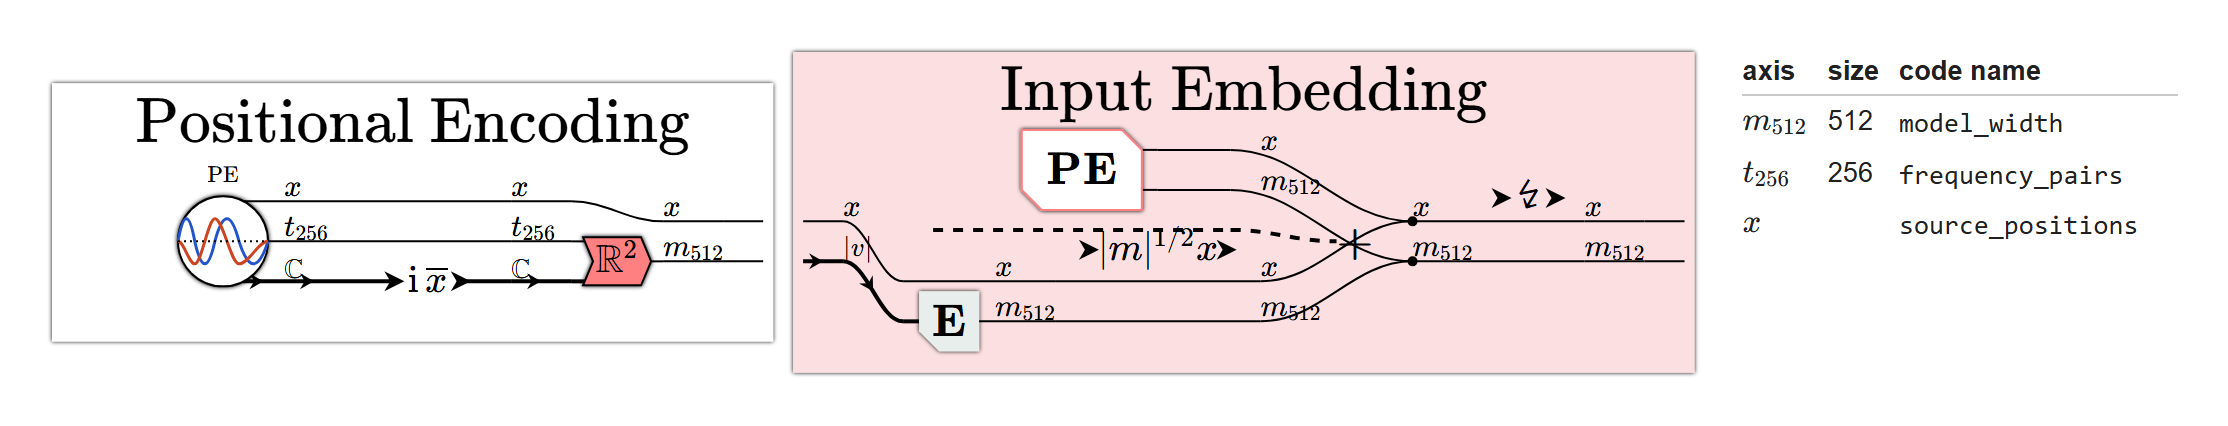

In [2]:
await figures.show(
    attention_is_all_you_need.embed(attention_is_all_you_need.x, attention_is_all_you_need.text.INPUT_EMBEDDING_TITLE,
                      attention_is_all_you_need.text.INPUT_EMBEDDING_DESCRIPTION),
    'The input embedding: the token identifiers embedded and scaled by the root of m, '
    'the positional encoding added as the box PE, whose body is drawn beside the '
    'figure, and dropout applied to the sum.',
    width=1000, settings=DIAGRAMS)

## Scaled dot-product attention in the self-attention of the encoder

Multi-head attention projects each position into $h = 8$ queries, keys and values of $k = 64$ values, computes scaled dot-product attention for every head, and maps the $h \times k$ values returned by the heads back to $m$ through $W^{O}$ (Section 3.2.2). The paper calls the step before $W^{O}$ a concatenation of the heads. In the expression the outputs of the heads form one array over the two axes $h$ and $k$, and $W^{O}$ contracts both axes, so no concatenation is written.

Scaled dot-product attention takes the dot product of each query with each key over the $k$ channels, divides the scores by $\sqrt{k}$, turns them into weights with a softmax over the keys, and returns the sum of the values under those weights (Section 3.2.1). In the self-attention of the encoder every source position reads every source position. The keys and the values are projected from the same copy of the source as the queries, so the score contraction carries the source axis at two positions, one for the query and one for the key. The expression reads an array by the positions of its axes, so the two positions are two indices, and the contraction returns the whole matrix of scores.

The self-attention of the encoder inside its Add & Norm block. The queries, keys and values are projected from one copy of the source, and scaled dot-product attention runs for every head.


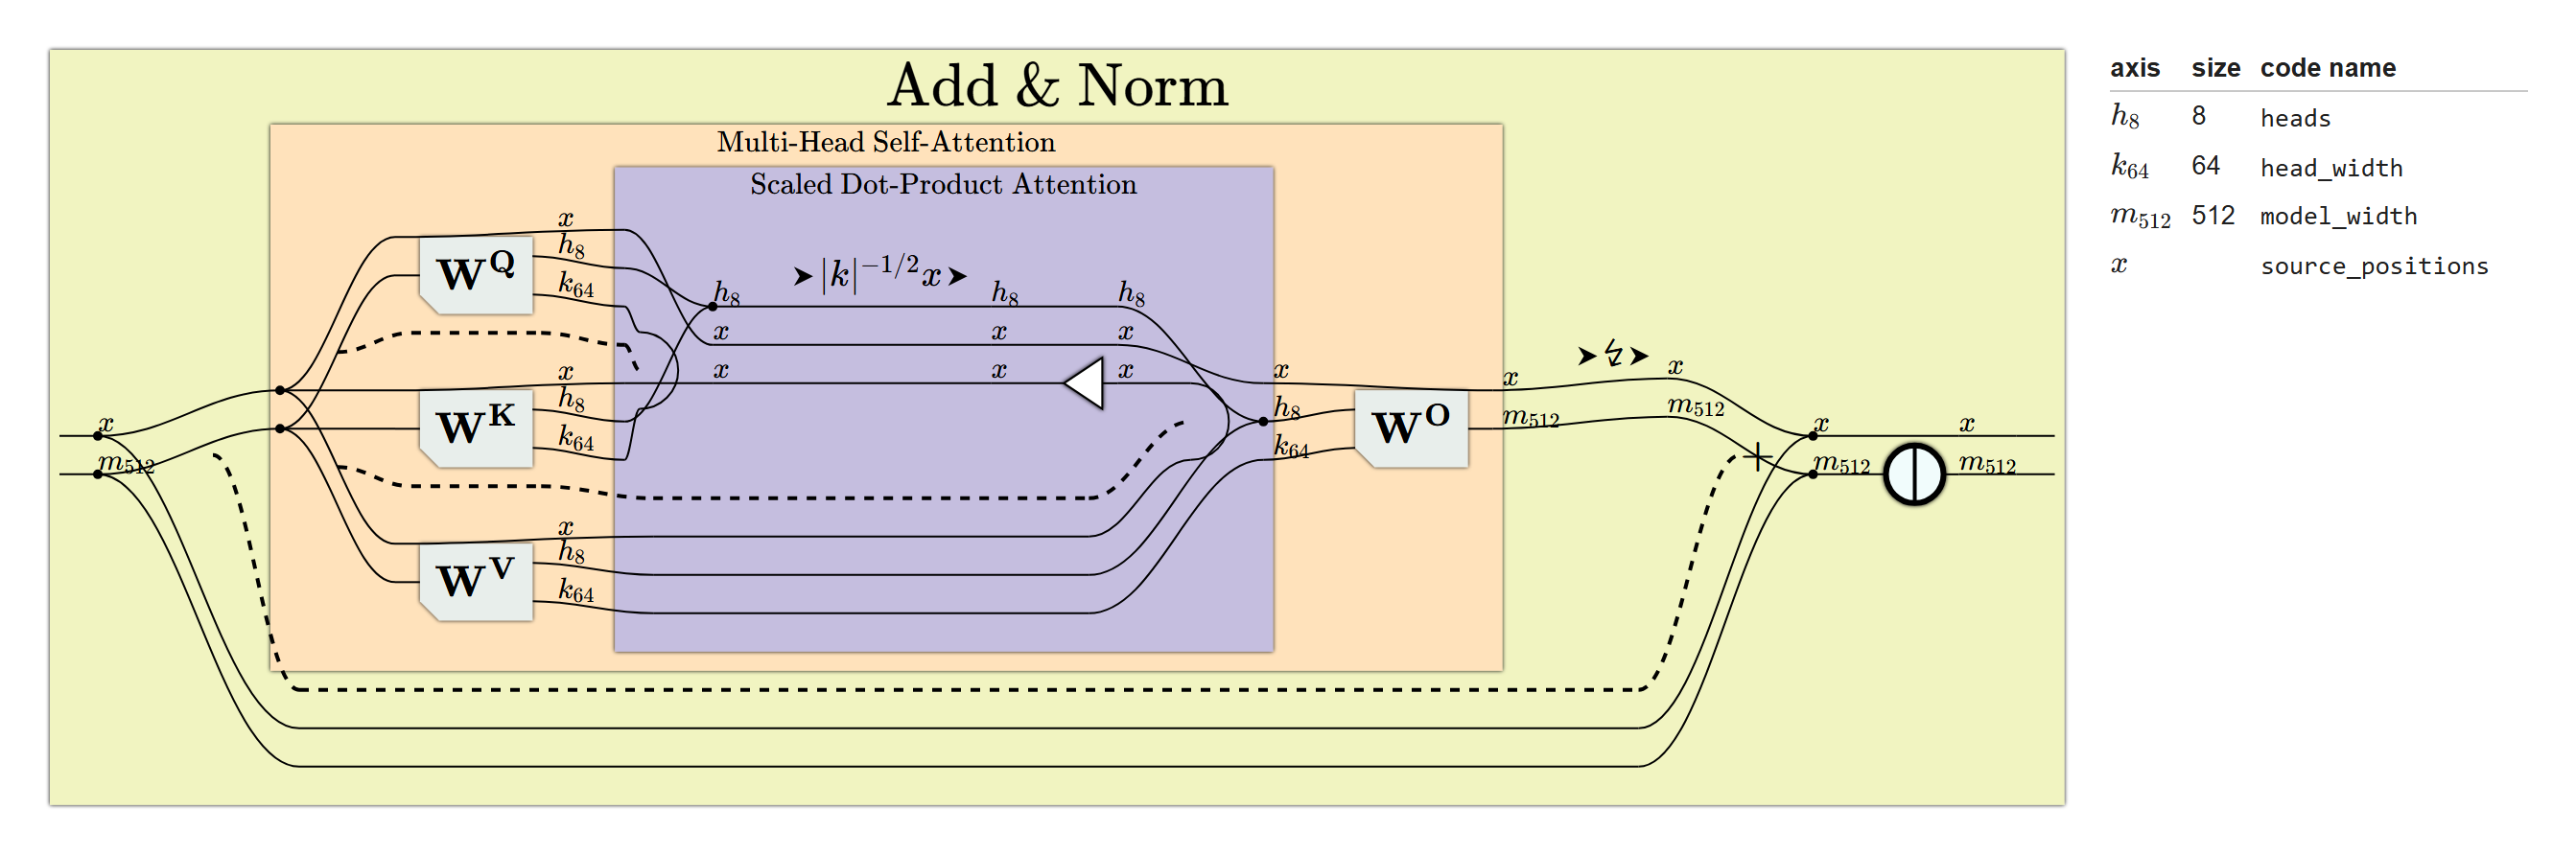

In [3]:
await figures.show(
    attention_is_all_you_need.add_and_norm(attention_is_all_you_need.encoder_self_attention(), attention_is_all_you_need.x),
    'The self-attention of the encoder inside its Add & Norm block. The queries, keys '
    'and values are projected from one copy of the source, and scaled dot-product '
    'attention runs for every head.',
    width=1600, settings=DIAGRAMS)

## The mask of the decoder as a read of the earlier positions

During training the decoder reads the whole target sentence at once, and each position is trained to predict the token at the next position. A target position must therefore be kept from reading the positions after it (Section 3.2.3). The paper sets the scores of those positions to $-\infty$ before the softmax. The expression states the same restriction as a read. The view named Mask reads, at slot $i_w$ of the query at position $i_y$, the target position $i_y - i_w$. Slot 0 is the query's own position, and slot $i_w$ is the position $i_w$ before it.

A read outside an axis returns the unit, a value skipped by every sum and every softmax. Slot $i_w$ of a query before position $i_w$ names a negative position, so the slots past the start of the sentence hold the unit. The view returns its slot axis as $w|y$, which records that slot $i_w$ holds a value where $i_y - i_w \geq 0$. The slot axis has the size of the target, so a query at position $i_y$ reads the $i_y + 1$ positions from the start of the sentence to itself. No mask operator and no $-\infty$ appear in the expression.

The projections $W^{K}$ and $W^{V}$ compute the same function at every position, so the view can read the input of the sublayer, with the projections after it, and the sublayer computes the same result. The figures draw every such read as early as it can stand, at the copy of the input that feeds the queries. $W^{K}$ and $W^{V}$ then run at every position and every slot, and they share one read of the input. Drawn at that point, the read shows every array that a cache of the earlier positions could hold, from the input of the sublayer to the keys and the values, and the section on the cached pass returns to those arrays.

The masked self-attention of the decoder inside its Add & Norm block. The view named Mask reads the input at the copy that feeds the queries, and W^K and W^V run at every target position and every slot of w|y.


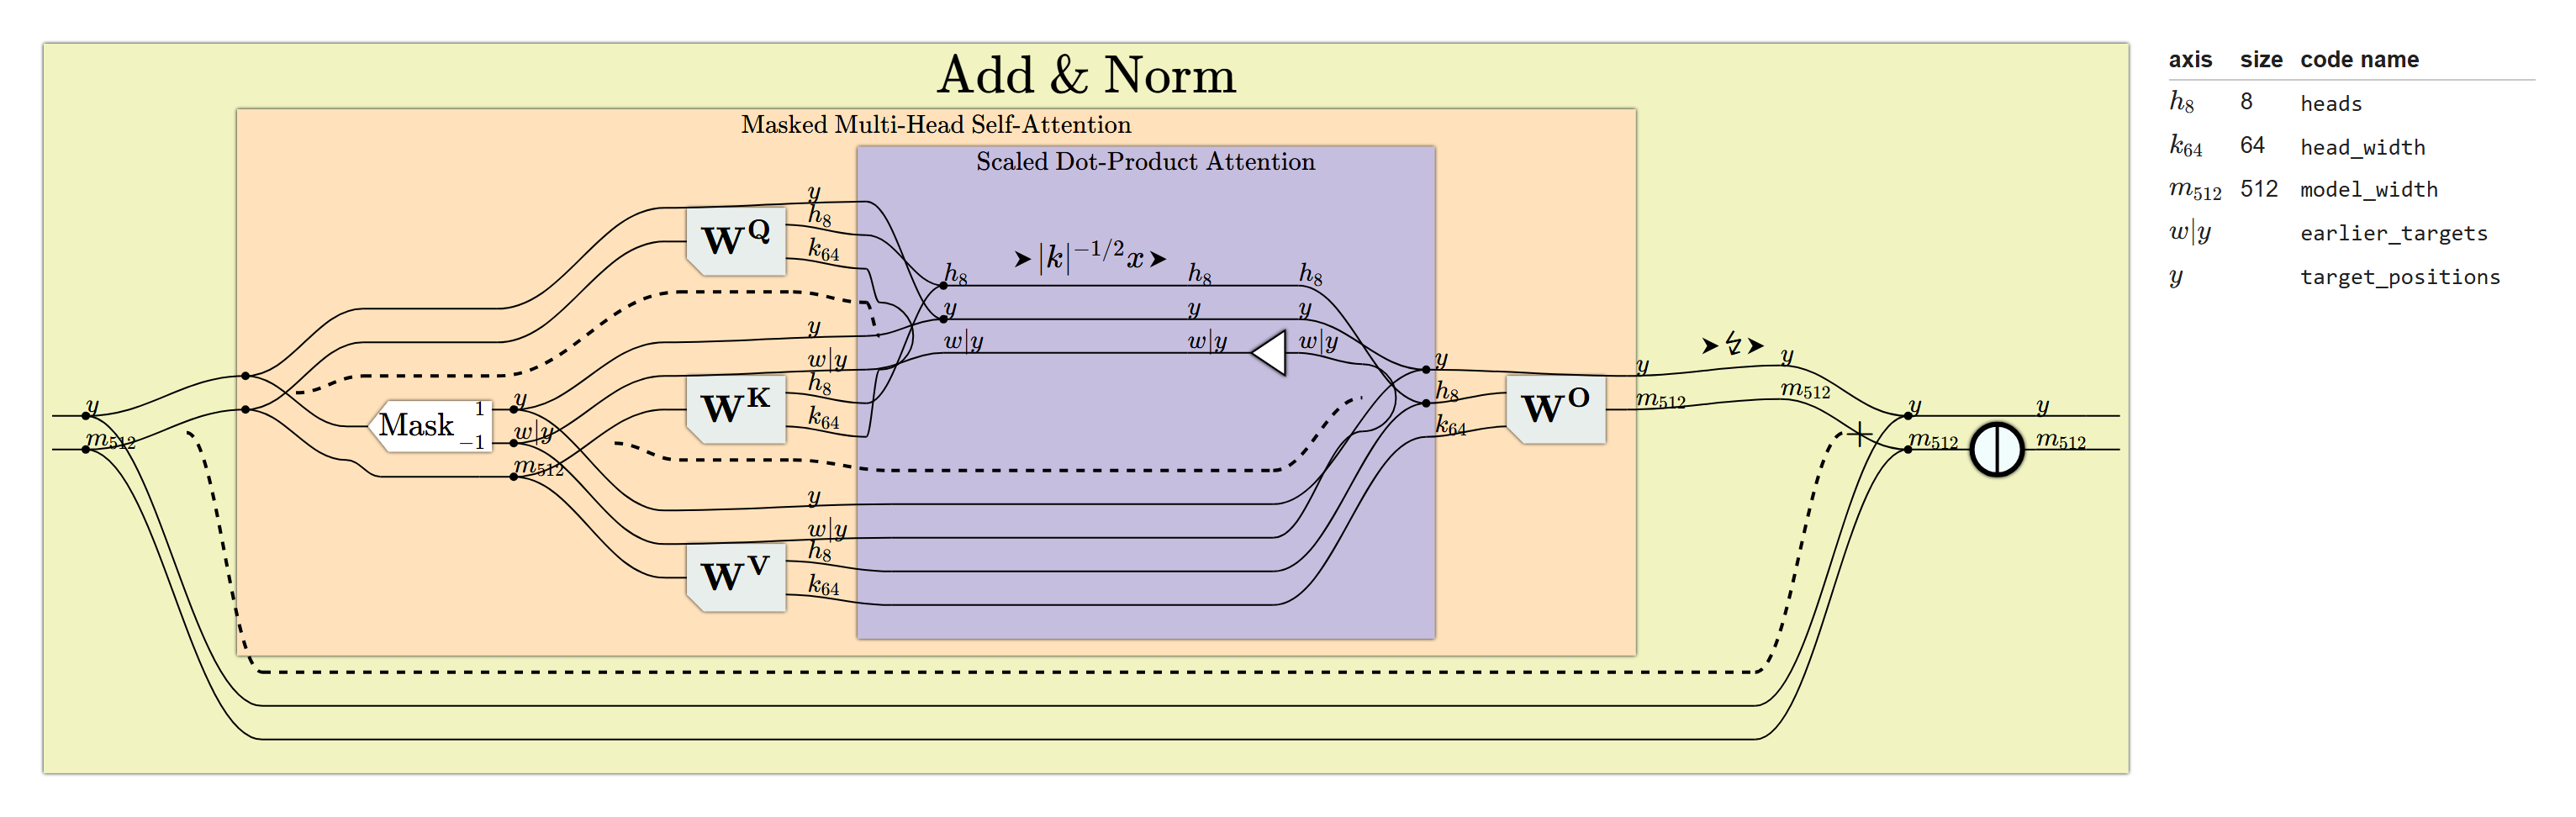

In [4]:
await figures.show(
    slide_causal_reads_backwards.slide_causal_reads_backwards(attention_is_all_you_need.add_and_norm(
        attention_is_all_you_need.decoder_masked_self_attention(), attention_is_all_you_need.y)),
    'The masked self-attention of the decoder inside its Add & Norm block. The view '
    'named Mask reads the input at the copy that feeds the queries, and W^K and W^V '
    'run at every target position and every slot of w|y.',
    width=1600, settings=DIAGRAMS)

## Cross-attention reads the encoded input from the tape

The output of the last encoder layer is the encoded input $A$. Every one of the $N = 6$ decoder layers reads it, so the expression writes it to the tape slot $A$ once, at the end of the encoder, and each cross-attention reads it from that slot. The queries come from the target positions and the keys and the values from the source positions, so every target position reads the whole source sentence. The hand-drawn diagram draws $A$ as the teal box entering each decoder layer, and the figure draws it as the slot $A$ arriving at the key and value projections.

The cross-attention of the decoder inside its Add & Norm block. The encoded input is read from the tape slot A, and the target positions query the source positions.


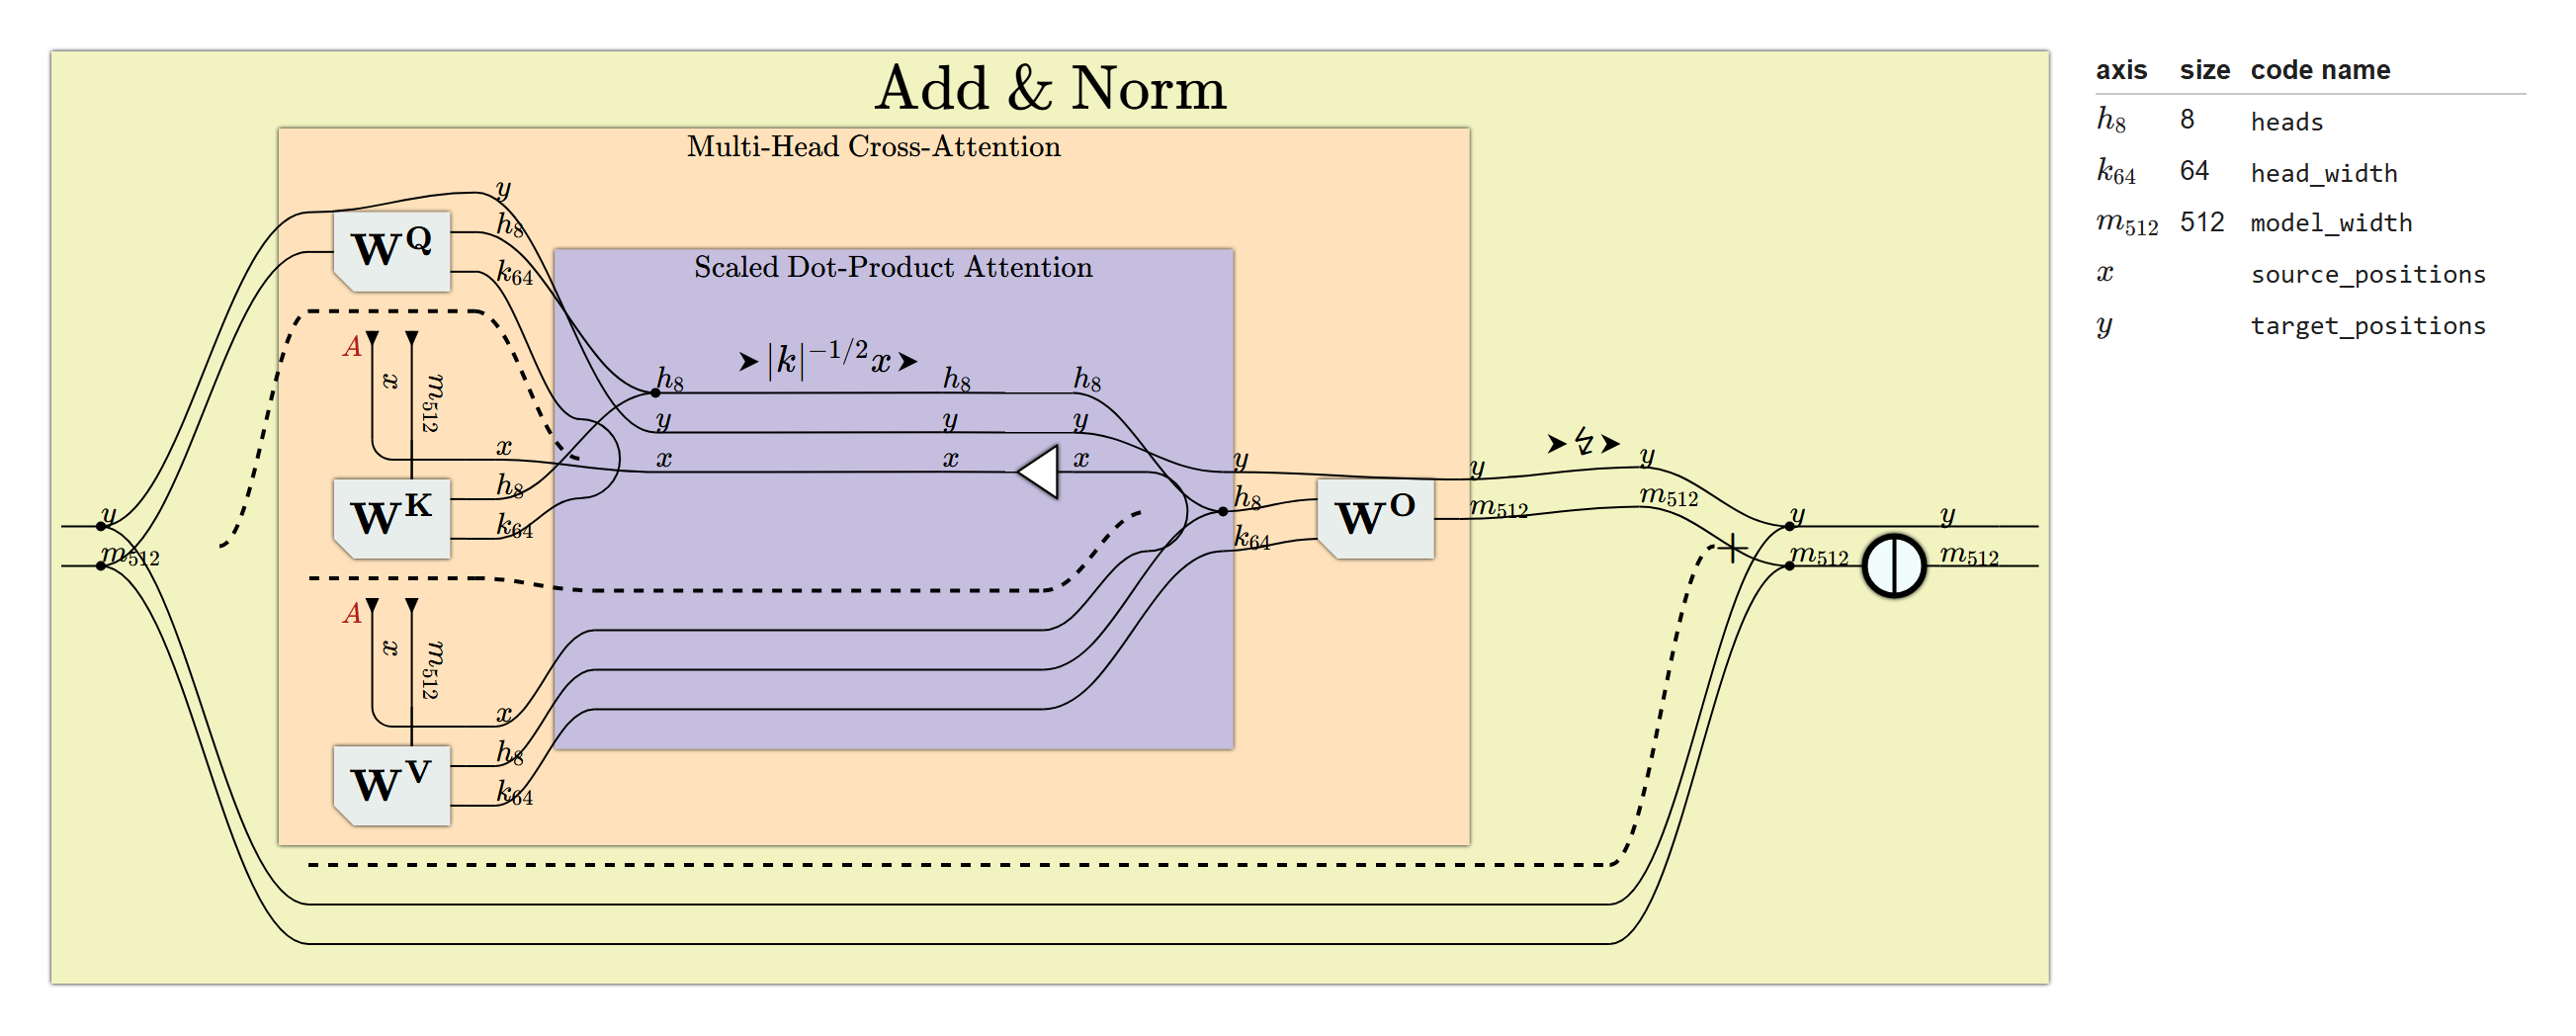

In [5]:
await figures.show(
    attention_is_all_you_need.add_and_norm(attention_is_all_you_need.decoder_cross_attention(), attention_is_all_you_need.y),
    'The cross-attention of the decoder inside its Add & Norm block. The encoded input '
    'is read from the tape slot A, and the target positions query the source '
    'positions.',
    width=1600, settings=DIAGRAMS)

## The feed-forward layer and the layer normalisation

The feed-forward layer applies $\mathrm{FFN}(z) = \max(0, z W_1 + b_1) W_2 + b_2$ to every position with the same weights (Section 3.3). Its inner width is $f = 2048$. The rectified linear unit is written as an elementwise map with its own formula, $y = \mathrm{ReLU}(x)$.

Every sublayer stands inside an Add & Norm block, which computes $\mathrm{LayerNorm}(z + \mathrm{Dropout}(\mathrm{Sublayer}(z)))$ (Sections 3.1 and 5.4). A layer normalisation subtracts the mean over the $m$ channels of a position, divides by the standard deviation over the same channels, multiplies by a learned gain and adds a learned bias. The figure draws it as the circle crossed by a vertical line, which is the glyph given to it by the hand-drawn diagram.

The feed-forward layer inside its Add & Norm block: two linear maps with biases and a rectified linear unit between them, dropout on the output, the residual addition and the layer normalisation.


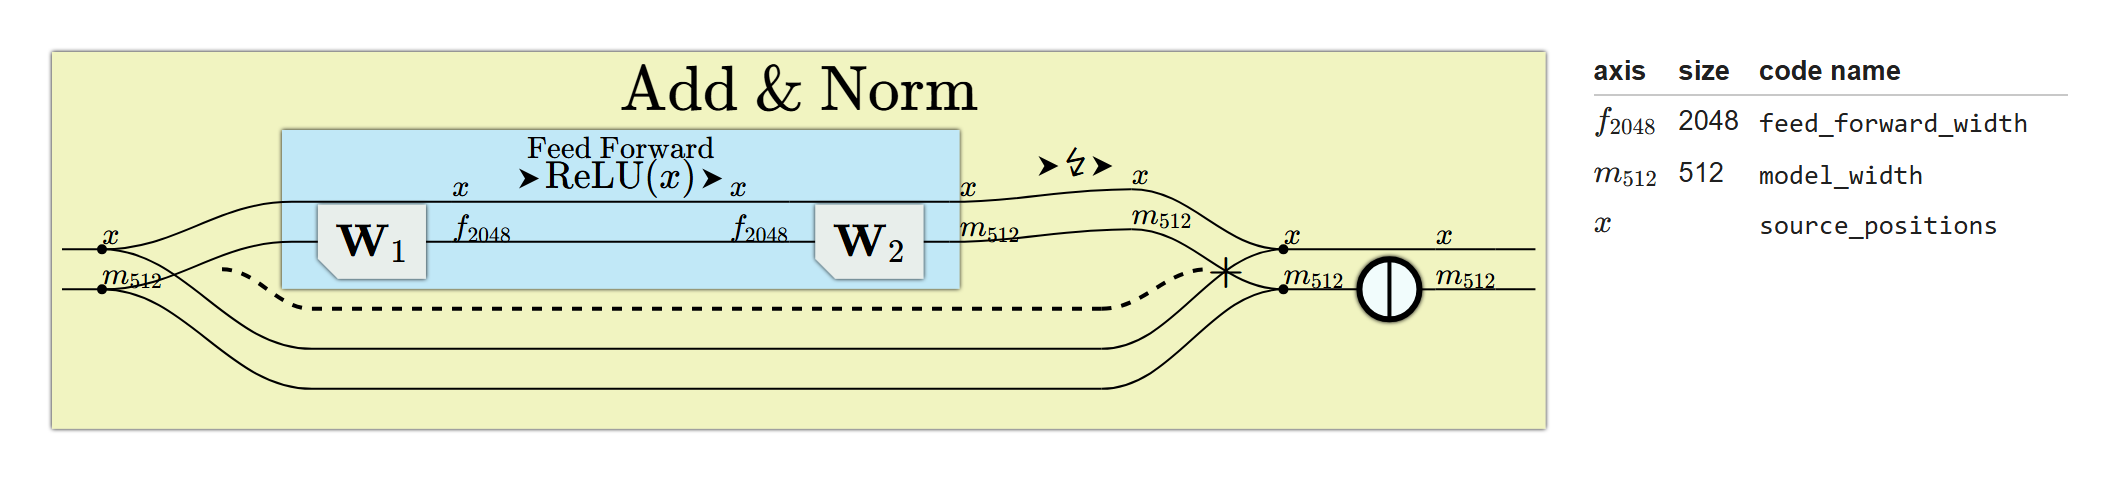

In [6]:
await figures.show(
    attention_is_all_you_need.add_and_norm(attention_is_all_you_need.feed_forward(attention_is_all_you_need.x), attention_is_all_you_need.x),
    'The feed-forward layer inside its Add & Norm block: two linear maps with biases '
    'and a rectified linear unit between them, dropout on the output, the residual '
    'addition and the layer normalisation.',
    width=1400, settings=DIAGRAMS)

## The encoder stack and the decoder stack

The encoder is a stack of $N = 6$ layers, and each layer is a self-attention sublayer followed by a feed-forward sublayer. The decoder is a stack of $N = 6$ layers, and each layer is a masked self-attention sublayer, a cross-attention sublayer and a feed-forward sublayer (Section 3.1). A stack is a block whose repetition is the symbol $N$, bound to 6 in the base model, so each stack draws one layer and the bracket at its left gives the number of layers. Every layer has weights of its own. A repeated block returns the array it reads, so each stack reads and returns one vector of width $m$ per position.

One decoder layer, repeated N times: masked self-attention, cross-attention reading the encoded input from the tape, and the feed-forward layer, each inside its Add & Norm block. The feed-forward layer starts the second row.


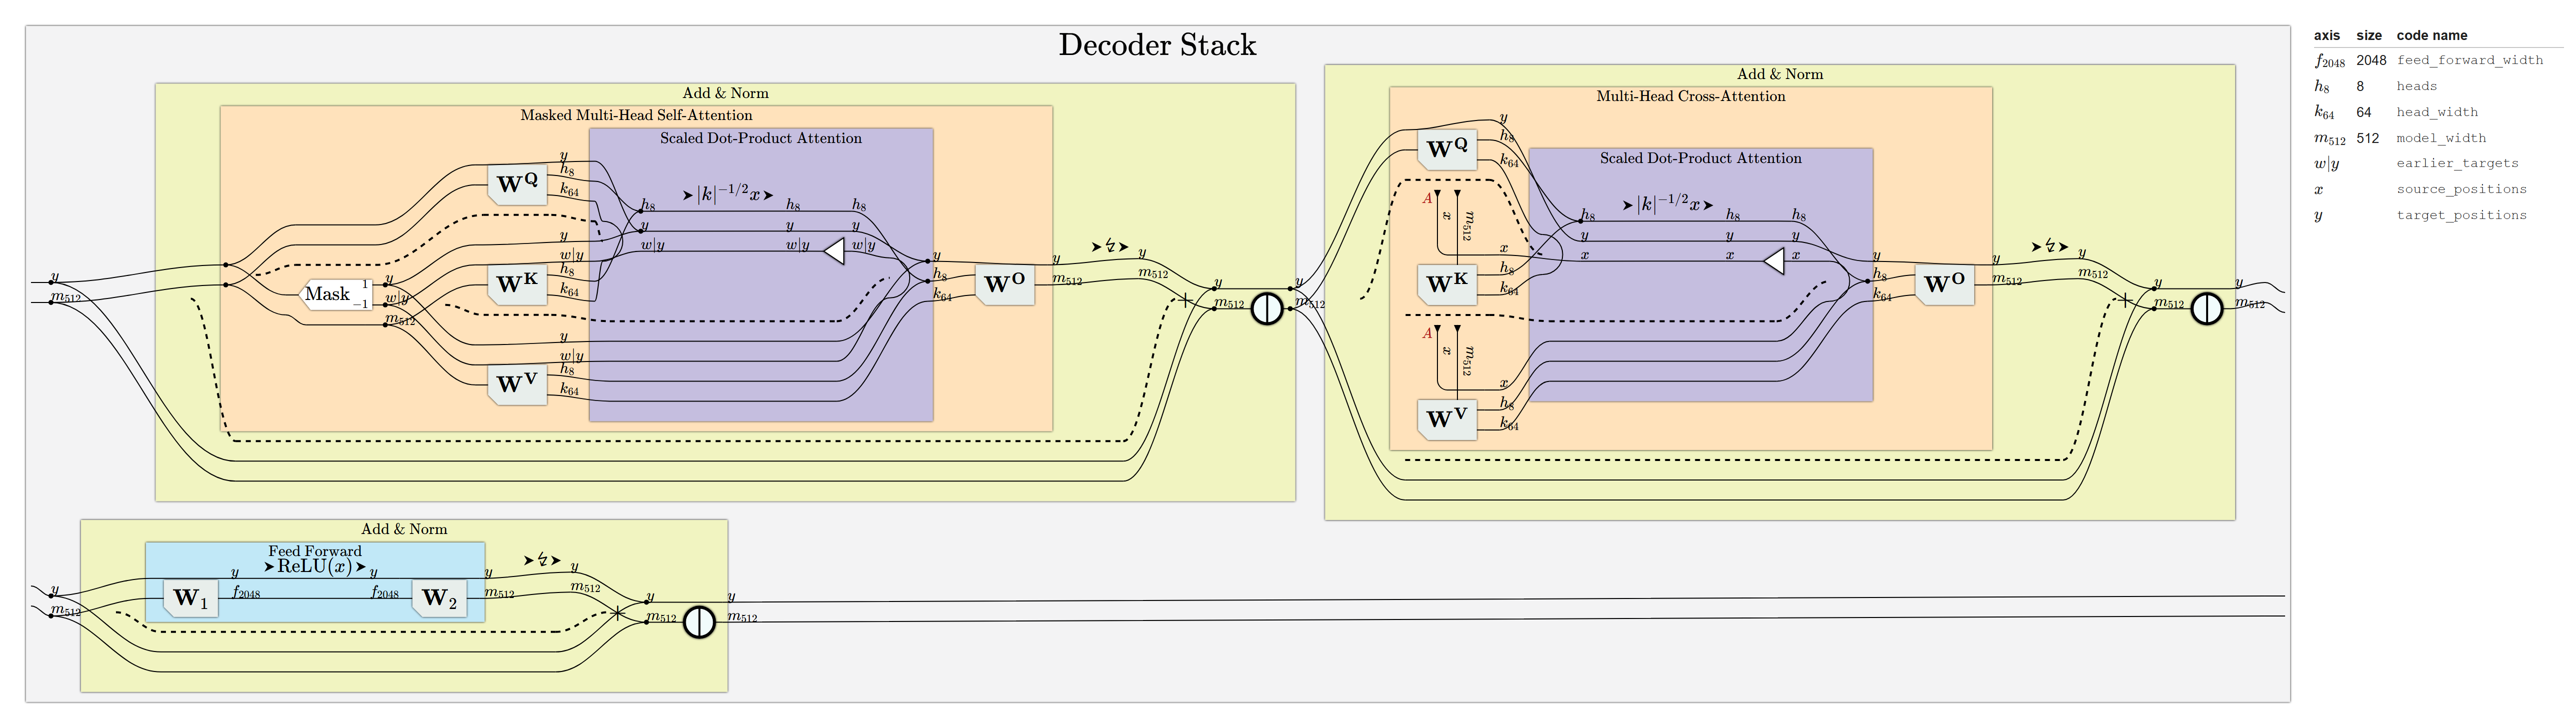

In [7]:
await figures.show(
    slide_causal_reads_backwards.slide_causal_reads_backwards(attention_is_all_you_need.decoder_stack()),
    'One decoder layer, repeated N times: masked self-attention, cross-attention '
    'reading the encoded input from the tape, and the feed-forward layer, each inside '
    'its Add & Norm block. The feed-forward layer starts the second row.',
    width=2175, settings=DIAGRAMS)

## The whole model

The source path embeds the source, runs the encoder stack and writes the encoded input to the tape. The target path embeds the target, runs the decoder stack, and maps each target position to a score for every token of the vocabulary through $E^{\top}$, and a softmax over the vocabulary turns the scores into probabilities (Section 3.4). The paper shares one weight matrix between the two embeddings and $E^{\top}$. The expression names all three operators after that matrix, and it holds them as three operators, since no term of the package states that two operators share one weight.

The figure draws the read of the mask at the copy of the input of the masked self-attention, as the section on the mask describes. The interactive page draws the same expression as its Decode form. The Decode form holds no cache, so every step of a translation runs it over every target position generated so far.

The transformer: the encoder on the source, the encoded input written to the tape, and the decoder on the target reading it in every layer, followed by the output probabilities, with the body of the box PE left out. The second row starts at the output embedding, and the third row at the dropout of the cross-attention.


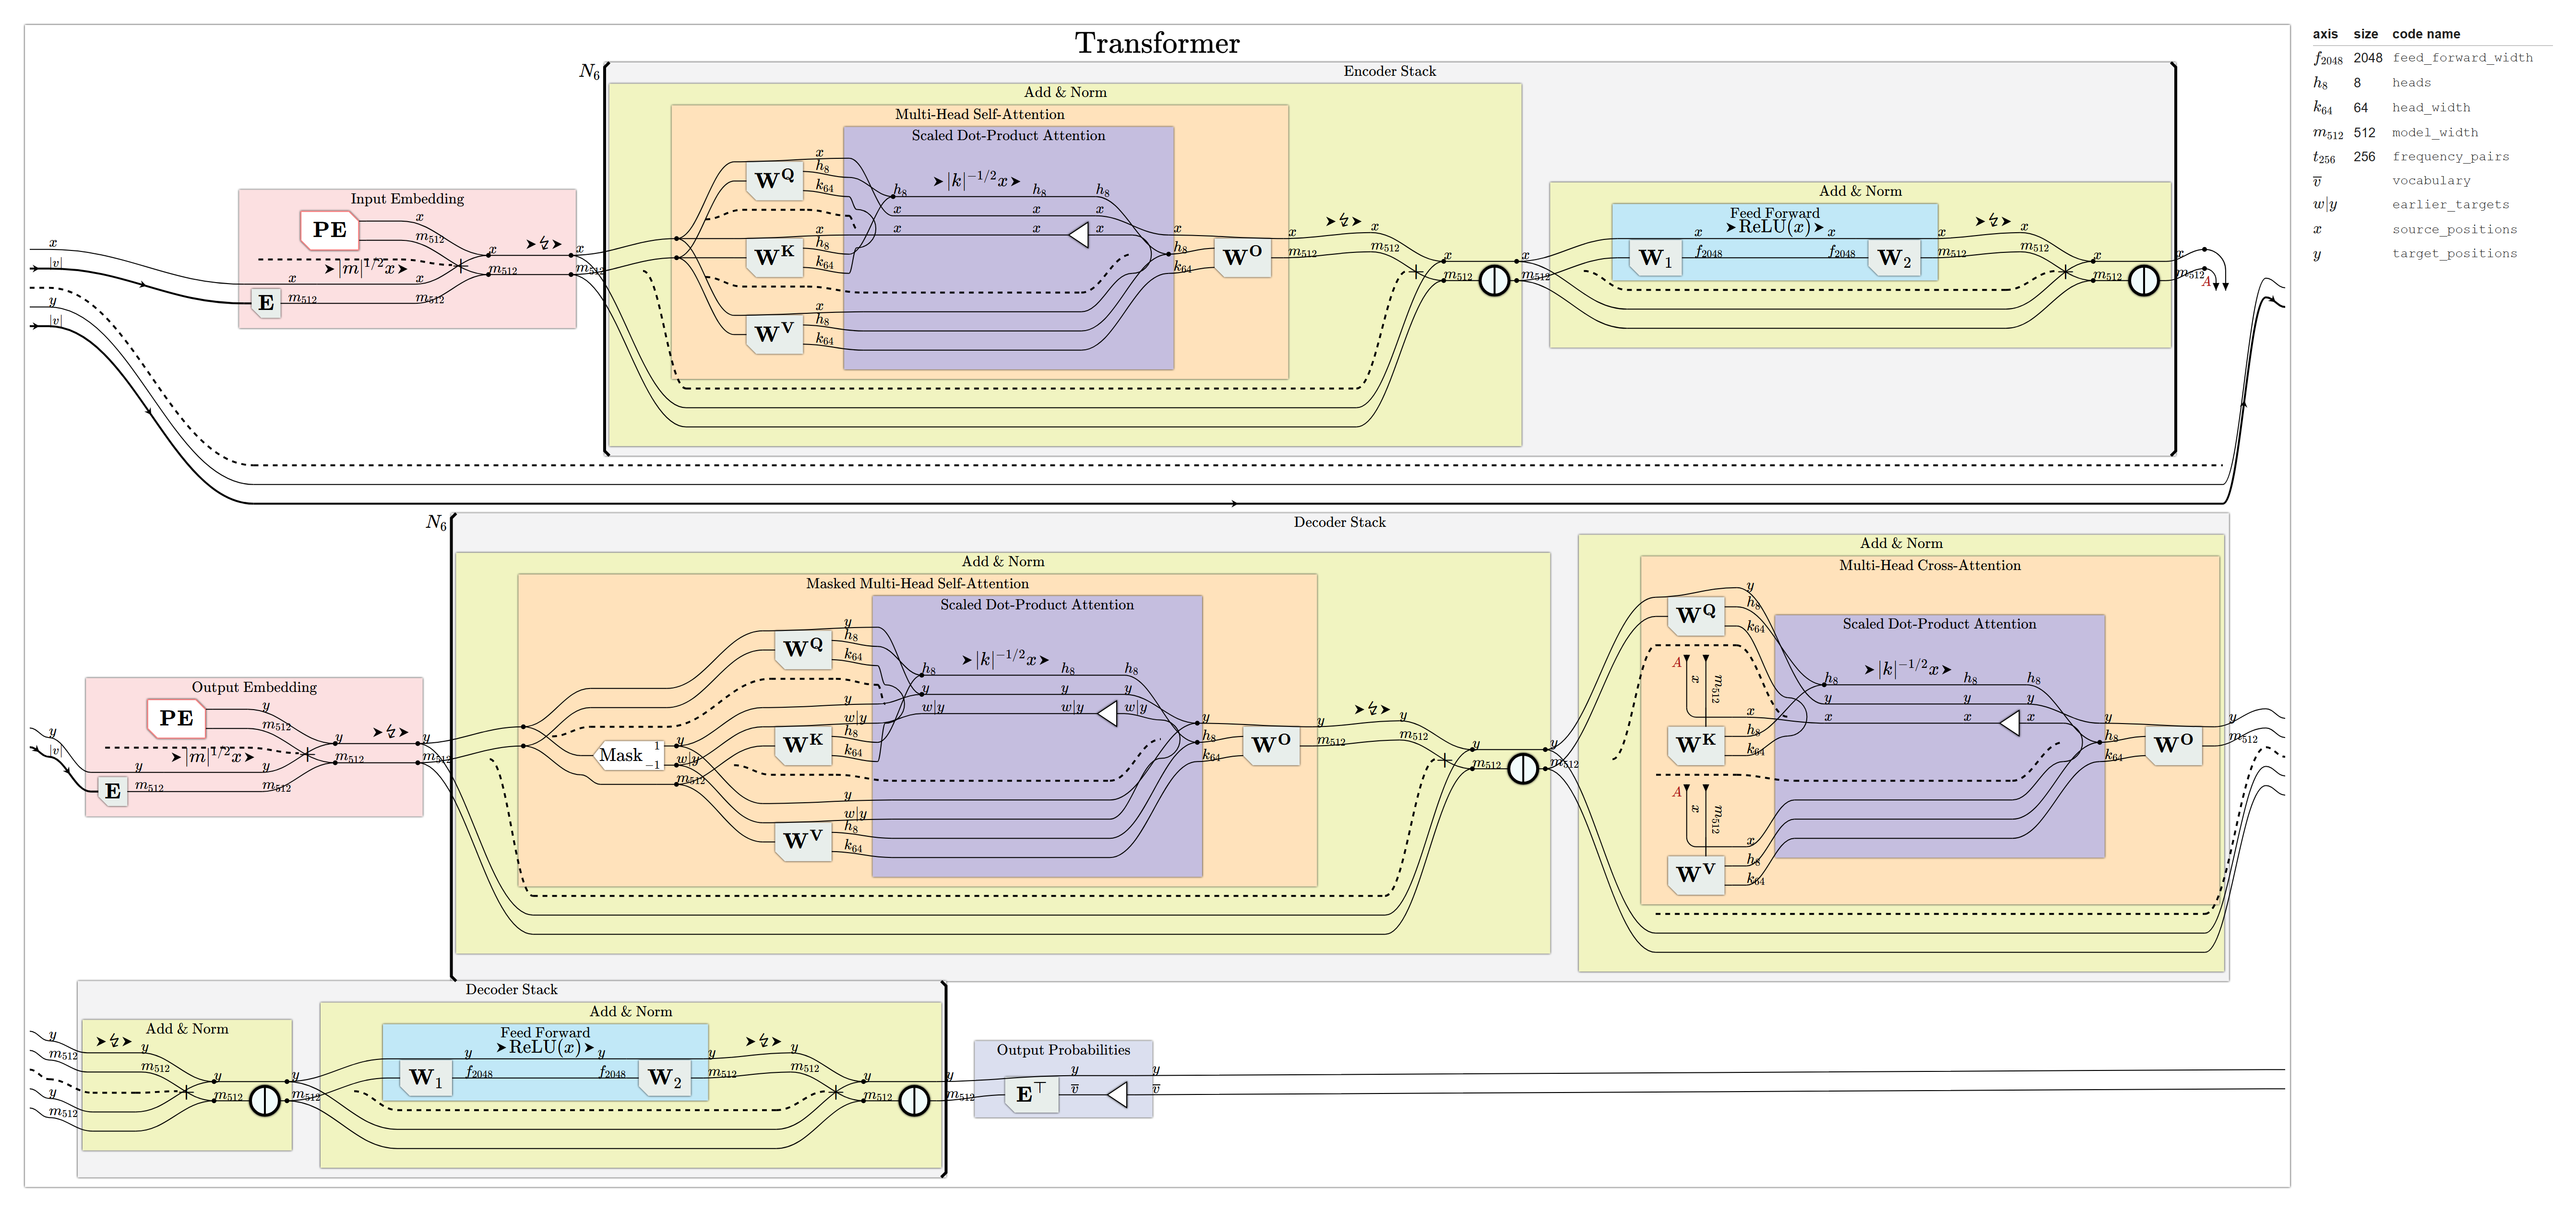

In [8]:
await figures.show(
    DECODE,
    'The transformer: the encoder on the source, the encoded input written to the '
    'tape, and the decoder on the target reading it in every layer, followed by the '
    'output probabilities, with the body of the box PE left out. The second row starts '
    'at the output embedding, and the third row at the dropout of the cross-attention.',
    width=2270, sub_blocks=figures.SubBlocks.NO_BODIES, settings=DIAGRAMS)

## The sizes of the base model

The configuration binds the sizes of the base model of Table 3. The vocabulary and the two sentence lengths stay symbols, because the paper gives the vocabulary as about 37000 tokens and the lengths are set by the input. The constants below are named in the expression and bound in the text.

| symbol | value | meaning | source |
| --- | --- | --- | --- |
| $N$ | 6 | the number of layers in each stack | Section 3.1 |
| $\beta$ | 10000 | the base of the frequencies of the positional encoding | Section 3.5 |
| $P_{\mathrm{drop}}$ | 0.1 | the dropout rate of the base model | Section 5.4 |
| $\epsilon$ | $10^{-6}$ | the number added to the variance of every layer normalisation | tensor2tensor `common_hparams.py` L144, not stated in the paper |

In [9]:
for name, size in CONFIG.assigned_integers_by_name().items():
    print(f'{name:>3} = {size}')

  m = 512
  h = 8
  k = 64
  f = 2048
  N = 6


## The quantisations of tensor2tensor

A quantisation is the number format a value is held in, together with the size of that format in bits. The paper links its code, tensor2tensor, and trained the base model on one machine with eight P100 GPUs (Section 5.2). tensor2tensor holds every activation and every weight of the base model in FP32. The defaults of its hyperparameters set `activation_dtype` and `weight_dtype` to `float32`, and `transformer_base_v1` starts from those defaults and changes neither. The model converts a value to another format only when `activation_dtype` names a 16-bit format, `bfloat16` or `float16`, or `weight_dtype` names `bfloat16`, so the base model converts no real value.

The input pipeline converts the token identifiers from `int64` to `int32` before the model reads them. The beam search used to decode takes the identifier of each next token from `tf.nn.top_k`, which returns `int32`. The paper decodes with a beam of four (Section 6.1), and four is also the default beam of tensor2tensor.

The quantised model therefore holds FP32 on every wire that carries a real number and INT32 on the two wires of token identifiers. No operation requires a value in another quantisation, so the expression holds no cast, and every weight is read in FP32. The figure below labels every wire with its quantisation. The lines of tensor2tensor were read at commit `bafdc1b` on 2026-09-27.

| quantisation | what it applies to | tensor2tensor |
| --- | --- | --- |
| FP32 | every activation, including the scores, the softmax and the layer normalisations | [`common_hparams.py` L266-L272](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_hparams.py#L266-L272), [`transformer.py` L1772-L1774](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L1772-L1774), [`t2t_model.py` L422-L425](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/utils/t2t_model.py#L422-L425), [`common_attention.py` L68-L83](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_attention.py#L68-L83), [`common_attention.py` L1650-L1658](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_attention.py#L1650-L1658) |
| FP32 | every weight, including the embedding shared with the output projection | [`common_hparams.py` L273-L279](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_hparams.py#L273-L279), [`t2t_model.py` L286-L300](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/utils/t2t_model.py#L286-L300), [`modalities.py` L456-L478](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/modalities.py#L456-L478) |
| INT32 | the token identifiers read in training | [`data_reader.py` L35-L41](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/utils/data_reader.py#L35-L41), [`data_reader.py` L392](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/utils/data_reader.py#L392) |
| INT32 | the token identifiers read in beam search | [`beam_search.py` L618-L625](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/utils/beam_search.py#L618-L625), [`decoding.py` L57-L58](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/utils/decoding.py#L57-L58) |

The transformer with the quantisations of tensor2tensor: FP32 on every wire holding a real number and INT32 on the token identifiers, with no cast. The rows break where the rows of the figure above break.


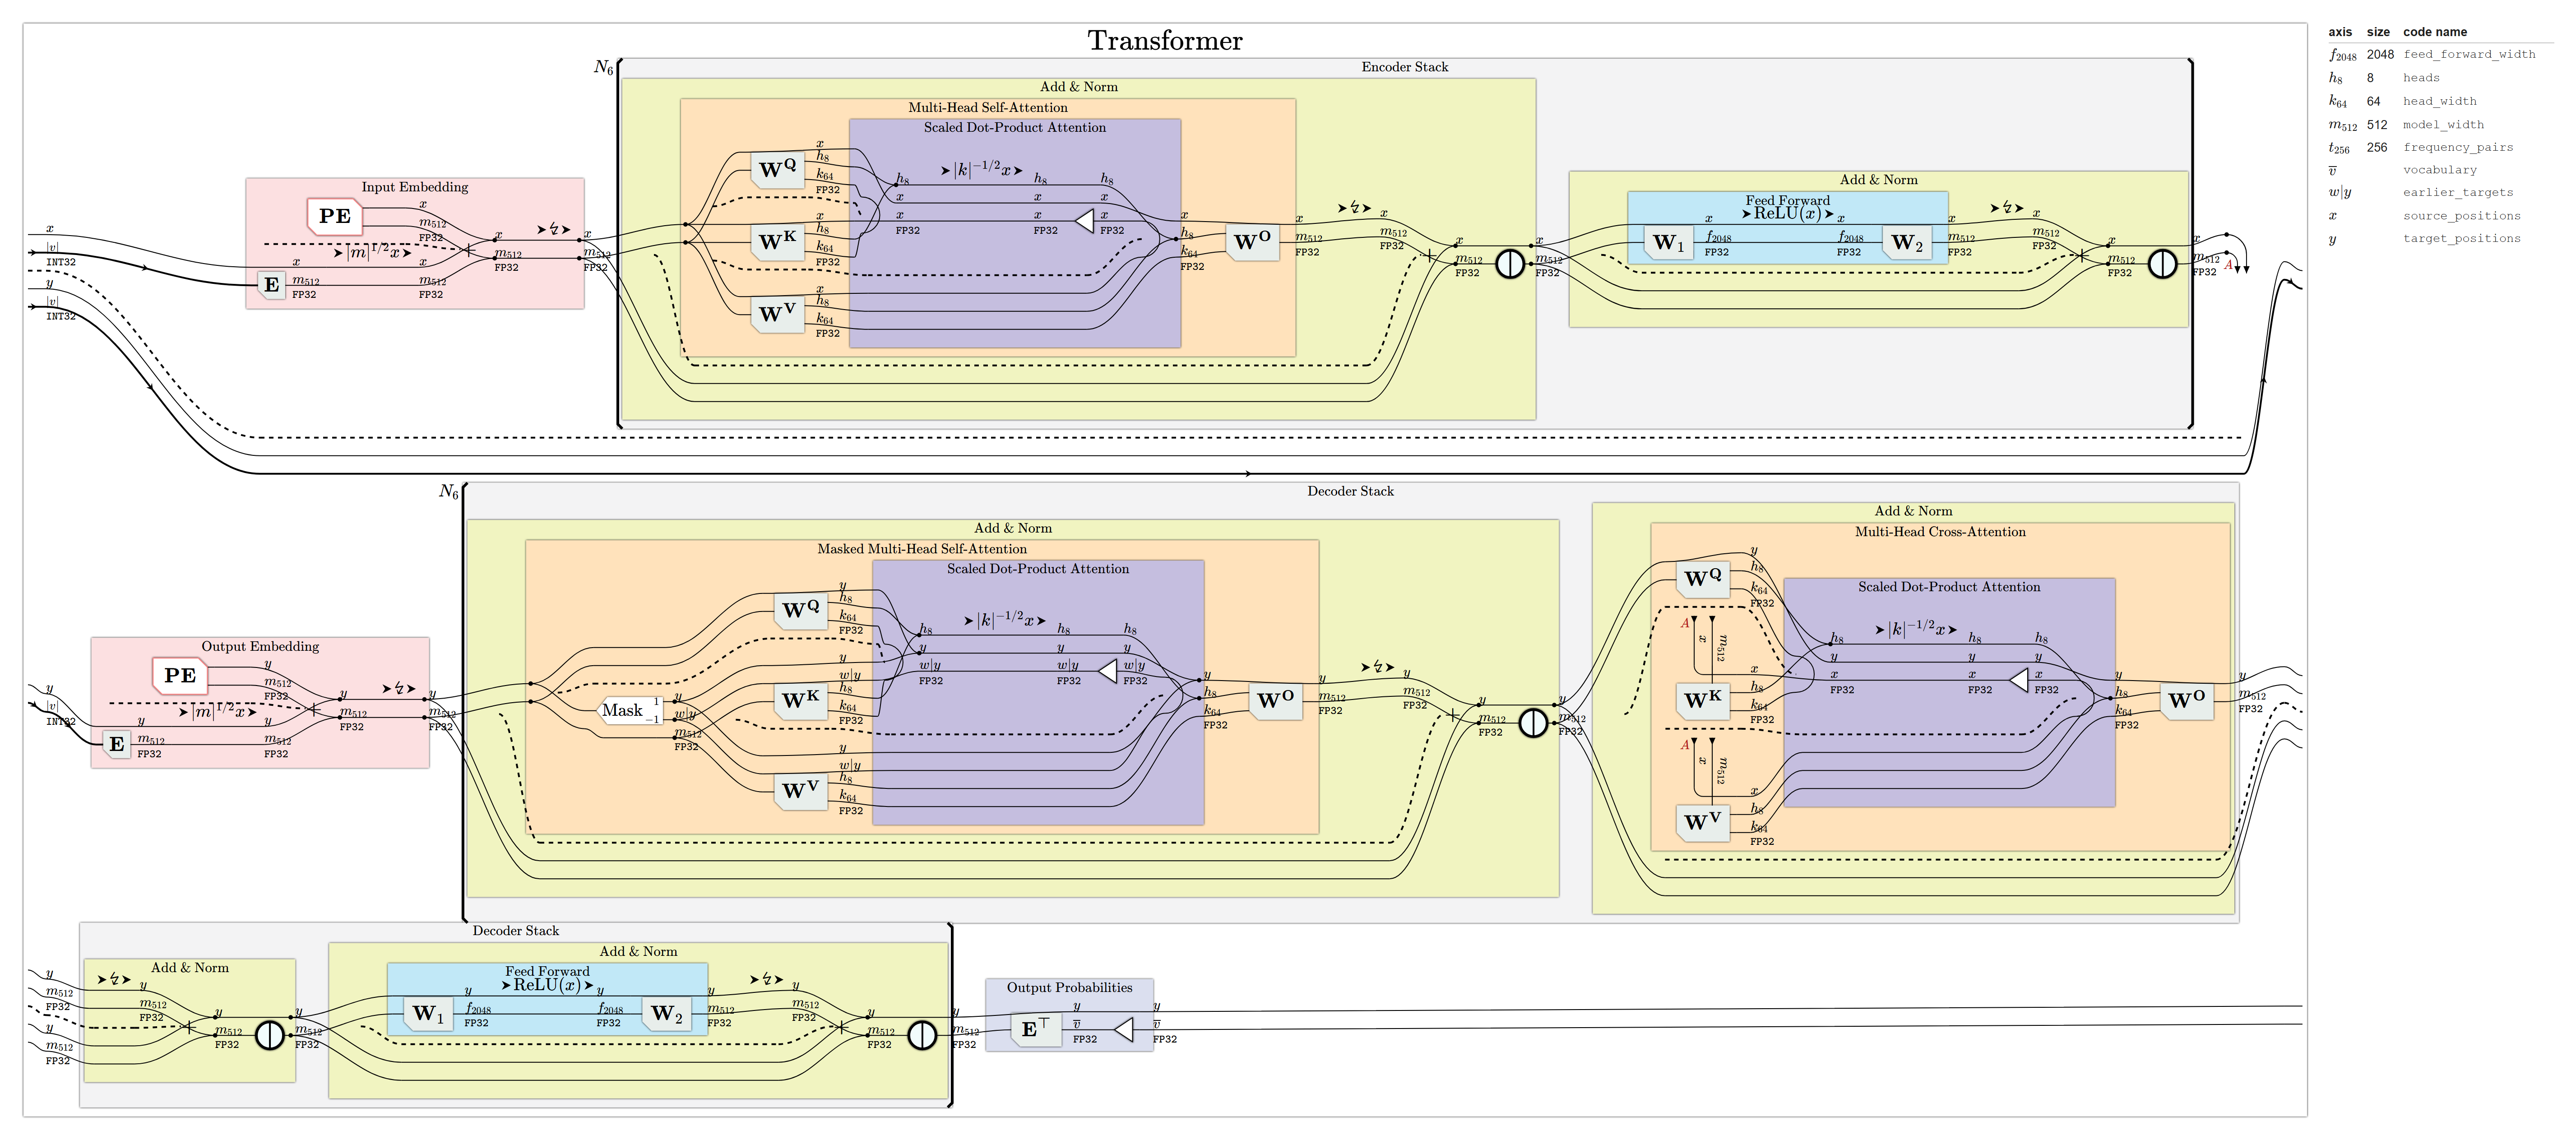

In [10]:
await figures.show(
    QUANTISED_DECODE,
    'The transformer with the quantisations of tensor2tensor: FP32 on every wire '
    'holding a real number and INT32 on the token identifiers, with no cast. The rows '
    'break where the rows of the figure above break.',
    width=2440, sub_blocks=figures.SubBlocks.NO_BODIES,
    settings=QUANTISED_DIAGRAMS)

## The cached pass of the decoder

A translation is generated one target token at a time, and each step runs the decoder again on the target tokens generated so far. The step needs the results of the model at its own positions alone. The target axis $y$ is split into the positions of the earlier steps, $y_{old}$, and the positions of the current step, $y_{new}$, and the step reads the results of the model at the positions $\lvert y_{old} \rvert + i_{new}$. An operator that computes the same function at every position returns its result at those positions from its operand at the same positions. The read of the new positions therefore passes back through every such operator, which is then computed over $y_{new}$ alone.

The mask is the one place where the read reaches earlier positions. Composed with the read of the new positions, the mask reads position $\lvert y_{old} \rvert + i_{new} - i_w$, which lies before the new positions for most slots. The array read there is loaded from a cache over $y_{old} + y_{new}$. The cache holds the entries written by the earlier steps, and the current step appends the entries of its own positions. The positional encoding is computed over every position of $y_{old} + y_{new}$ and read at $\lvert y_{old} \rvert + i_{new}$ by the view named New.

A cache can stand after any operator between the copy of the input of the sublayer and the mask, and the operators after the cache are then computed at every cached position in every step. Moving each cache back past the operator it follows gives four placements in every decoder layer: a cache of the keys beside a cache of the values, a cache of the input of the sublayer for the keys beside a cache of the values, the same pair with the keys and the values exchanged, and one cache of the input for both.

tensor2tensor caches the keys and the values of every head directly after the projections $W^{K}$ and $W^{V}$, and appends the keys and the values of each step to them ([`common_attention.py` L4674-L4679](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_attention.py#L4674-L4679)). That placement computes no operator over the cache, and it is the pass drawn below. In each of the $N = 6$ layers the pass holds two caches of $h \cdot k = 512$ values per target position, so the caches of the decoder hold 6,144 values per target position. The positional encoding of the pass reads the table at $\lvert y_{old} \rvert + i_{new}$, and tensor2tensor likewise adds the slice `positional_encoding[:, i:i + 1]` of one table built for the whole translation ([`transformer.py` L763-L765](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L763-L765) and [`transformer.py` L812](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L812)).

One step of the decoder over the new target positions: W^K and W^V run at the new positions, their results are appended to the caches over y_old + y_new, and the view named Mask reads the caches at |y_old| + i_new - i_w. The feed-forward layer starts the second row.


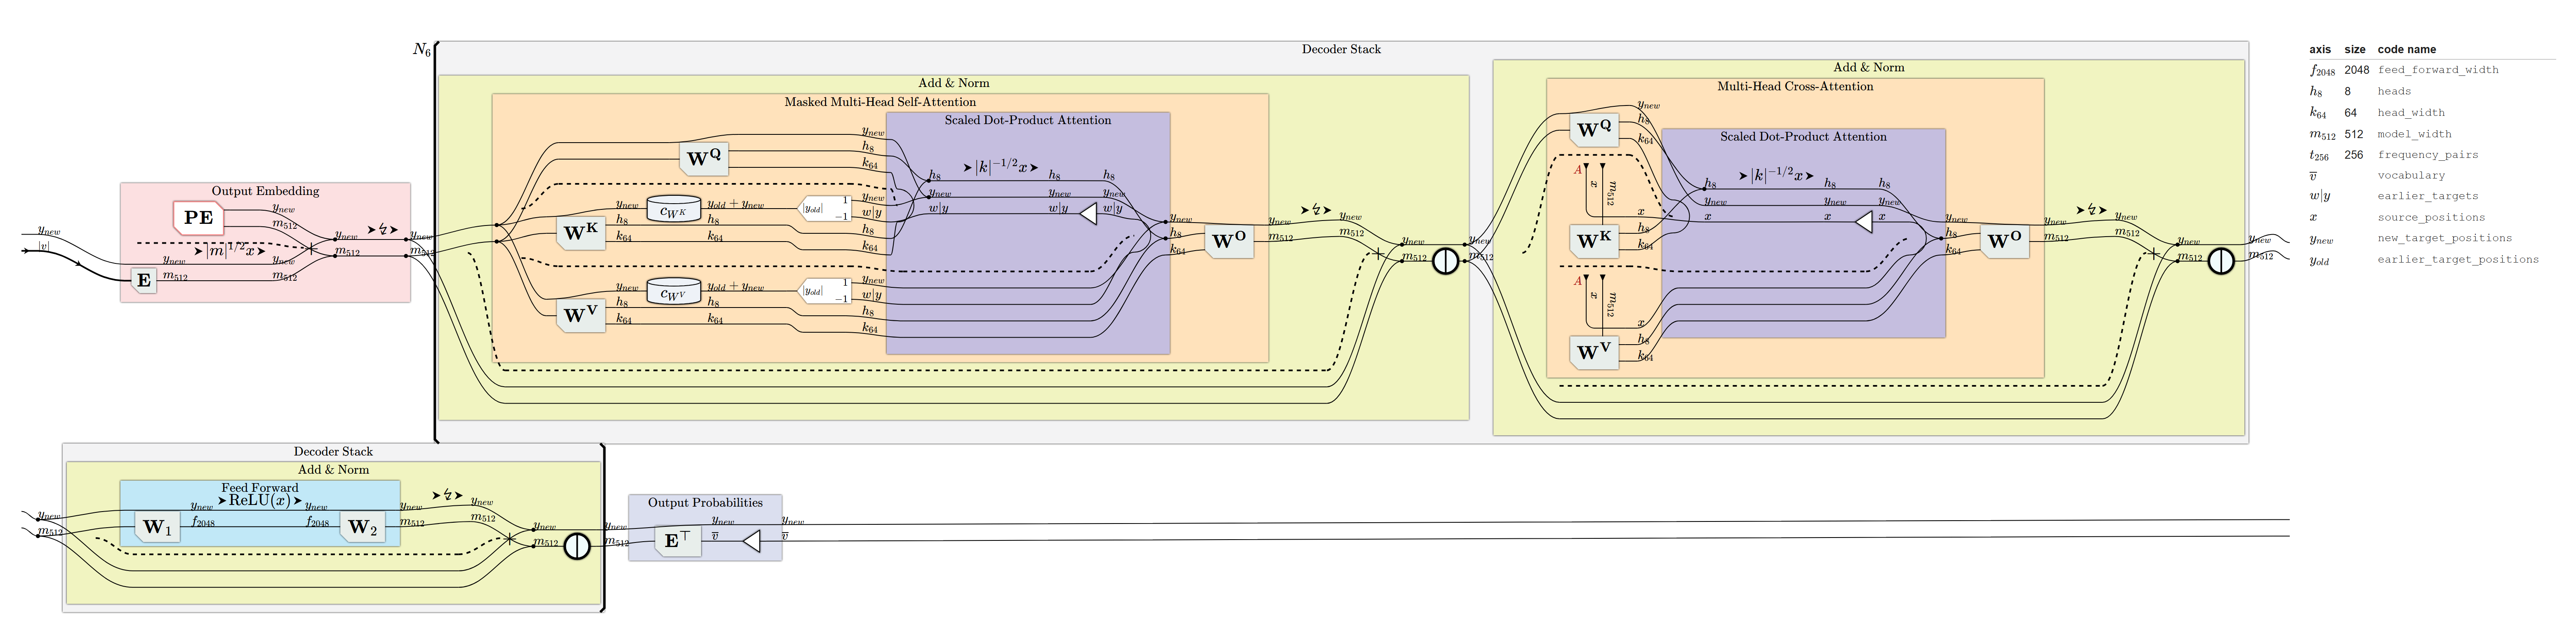

In [11]:
await figures.show(
    CACHED,
    'One step of the decoder over the new target positions: W^K and W^V run at the new '
    'positions, their results are appended to the caches over y_old + y_new, and the '
    'view named Mask reads the caches at |y_old| + i_new - i_w. The feed-forward layer '
    'starts the second row.',
    width=2650, sub_blocks=figures.SubBlocks.NO_BODIES, settings=DIAGRAMS)

## The encoder and the cross-attention in the cached pass

The encoder reads the source sentence and no target position, so the read of the new target positions never reaches it. Derived from the whole model, the pass keeps every operation over the source positions as the model writes it, and runs the encoder over the whole source sentence in every step. The pass of the decoder drawn above reads the encoded input $A$ from the tape, where the encoder writes it.

tensor2tensor runs the encoder once per sentence, before the first step ([`transformer.py` L730-L737](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L730-L737)). At the same point it projects the encoded input into the keys and the values of the cross-attention of every layer and keeps them for every step ([`transformer.py` L967-L988](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L967-L988) and [`common_attention.py` L4667-L4672](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_attention.py#L4667-L4672)). The pass drawn above projects $A$ into those keys and values again in every step. The derivation places a cache only where a read reaches earlier target positions, and no operator of the package states a value computed once per sentence and kept for every step. The projections of the cross-attention are therefore the one part of the reference missing from the derived pass.

## The quantisations of the cached pass

tensor2tensor starts each cache of a self-attention as an empty FP32 tensor, and each step concatenates its FP32 keys and values onto it ([`transformer.py` L942-L955](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L942-L955) and [`transformer.py` L1215-L1222](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L1215-L1222)). A cache holds its values in the quantisation they arrive with, so both caches of the quantised pass hold FP32, and the pass holds no cast.

One step of the decoder with the quantisations of tensor2tensor: the caches hold the keys and the values in FP32, and the token identifiers are INT32.


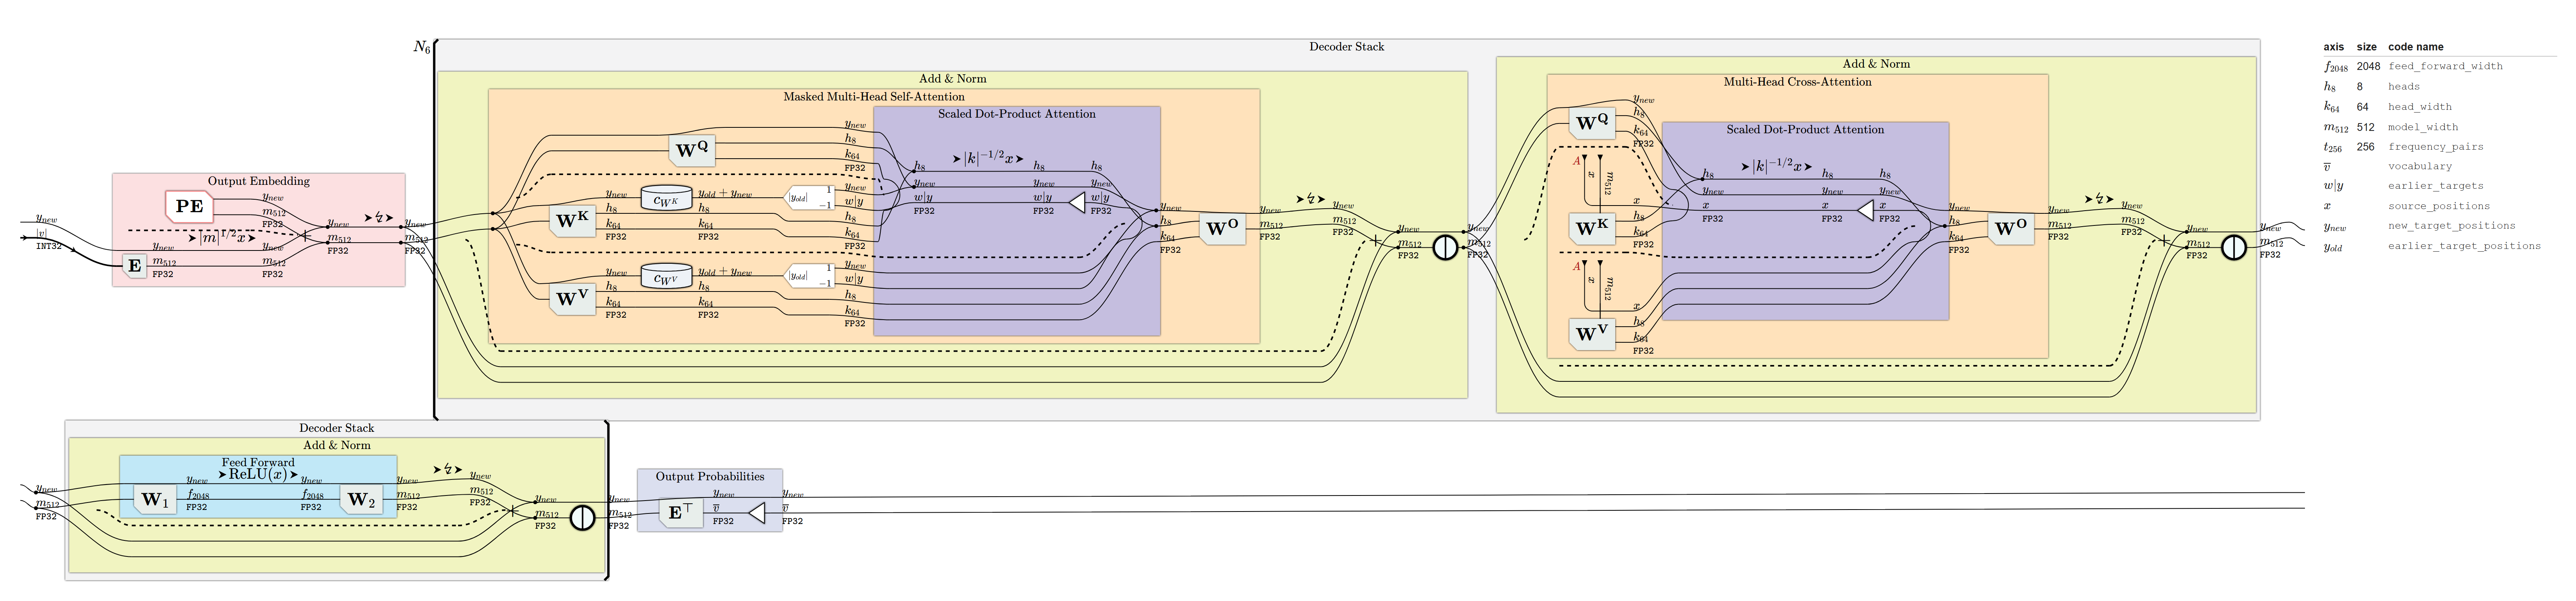

In [12]:
await figures.show(
    QUANTISED_CACHED,
    'One step of the decoder with the quantisations of tensor2tensor: the caches hold '
    'the keys and the values in FP32, and the token identifiers are INT32.',
    width=2825, sub_blocks=figures.SubBlocks.NO_BODIES,
    settings=QUANTISED_DIAGRAMS)

## The interactive page

The four variants of the model are written to `notebooks/website/output/classic/AttentionIsAllYouNeed/index.html`, one file that opens with no server and no network. `notebooks/classic/attention_is_all_you_need_page_variants.py` declares them. A selector above the figure switches between the Decode form, which is the whole model, and the Cached form, which is one step of the decoder, and between the quantised and the unquantised variant of each. The file holds the two quantised variants, and the browser derives each unquantised variant by removing every quantisation from the quantised variant. Resting the pointer on a block opens an inspection box with the block's title, its formula, its description and the sections of the paper expressed by the block. Resting it on the layer normalisation, a softmax or a linear map opens the operator written out in elementary operations, with the role of that operator in the model. Resting it on a dropout, the embedding, the positional encoding or the view named Mask opens the explanation of that operator. In the Cached form a cache opens its expansion, which reads the entries of the earlier positions from the tape, concatenates the entries of the new positions after them, and writes the whole back to the tape. The body of the positional encoding there holds the view named New, whose box explains the read of the new positions. A click locks a box, and the blocks and operators drawn inside a box open boxes of their own.

In [13]:
PAGE = dataclasses.replace(
    attention_is_all_you_need_page_variants.page_settings(QUANTISED_DIAGRAMS),
    page_directory=website_output.CLASSIC_PAGES)

await notebook_diagrams.show_page_variants(
    attention_is_all_you_need_page_variants.page_variants(QUANTISED_DECODE, QUANTISED_CACHED, PAGE),
    'The whole model and one cached step of its decoder, each with and without the '
    'quantisations of tensor2tensor, as one HTML file with an inspection box over '
    'every block and every operator.',
    settings=PAGE, slug=attention_is_all_you_need_page_variants.SLUG, initial=attention_is_all_you_need_page_variants.INITIAL_VARIANT)

The whole model and one cached step of its decoder, each with and without the quantisations of tensor2tensor, as one HTML file with an inspection box over every block and every operator.


(written to notebooks/website/output/classic/AttentionIsAllYouNeed/)


## Differences from the hand-drawn diagram

- The hand-drawn diagram applies dropout to the attention weights and after the rectified linear unit. The paper states dropout on the output of every sublayer and on the sum of the embedding and the positional encoding (Section 5.4), and its hyperparameters in tensor2tensor, `transformer_base_v1`, set the attention and ReLU dropouts to zero (`transformer.py` L1810 and L1812). The two further dropouts belong to `transformer_base_v2` (L1849 and L1850), which also moves the layer normalisation in front of each sublayer. The expression follows the paper.
- The diagram draws the output projection as a linear map with a bias. The paper shares its weight with the embeddings and states no bias, so the expression writes $E^{\top}$ with none.
- The diagram leaves out the multiplication of the embedded vectors by $\sqrt{m}$, which Section 3.4 states and the expression includes.
- The diagram names the source vocabulary $\bar{m}$ and the target vocabulary $\bar{m}'$. The paper encodes both sentences with one byte-pair vocabulary, so the expression reads both through one datatype over $\bar{v}$.
- The diagram draws the keys of the decoder at the same axis as the queries. The expression reads the input of the masked self-attention at `w|y` through the view named Mask, and the slot axis `w|y` takes the place of the mask drawn by the diagram.
- The diagram names the projections $L^{Q}$, $L^{K}$, $L^{V}$ and $L^{O}$, and the expression uses the names of the paper, $W^{Q}$, $W^{K}$, $W^{V}$, $W^{O}$, $W_1$ and $W_2$.

## The references

The paper is version 7 of arXiv [1706.03762](https://arxiv.org/pdf/1706.03762v7), read on 2026-09-23, and a block cites it by section. The code the paper links is `tensorflow/tensor2tensor`, read at commit [`bafdc1b`](https://github.com/tensorflow/tensor2tensor/tree/bafdc1b67730430d38d6ab802cbd51f9d053ba2e) on 2026-09-23 for the model and on 2026-09-27 for the quantisations and the caches.

| mechanism | paper | tensor2tensor |
| --- | --- | --- |
| encoder and decoder stacks, residual connections | Section 3.1 | [`common_hparams.py` L130-L133](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_hparams.py#L130-L133) |
| scaled dot-product attention | Section 3.2.1 | [`common_attention.py` L1650-L1658](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_attention.py#L1650-L1658) |
| multi-head attention and the mask | Sections 3.2.2 and 3.2.3 | [`transformer.py` L1802](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L1802) |
| feed-forward layer | Section 3.3 | [`transformer.py` L1797](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L1797) |
| embeddings and shared weights | Section 3.4 | [`modalities.py` L489-L506](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/modalities.py#L489-L506) |
| positional encoding | Section 3.5 | [`transformer.py` L763-L765](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L763-L765) |
| dropout | Section 5.4 | [`transformer.py` L1810-L1812](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L1810-L1812), [`transformer.py` L1843-L1852](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L1843-L1852) |
| epsilon of the layer normalisation | not stated | [`common_hparams.py` L142-L144](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_hparams.py#L142-L144) |
| hardware | Section 5.2 | |
| beam search | Section 6.1 | [`decoding.py` L57-L58](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/utils/decoding.py#L57-L58) |
| quantisations | not stated | [`common_hparams.py` L266-L279](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_hparams.py#L266-L279), [`data_reader.py` L35-L41](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/utils/data_reader.py#L35-L41) |
| the caches of the self-attention and the cross-attention | not stated | [`transformer.py` L930-L990](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L930-L990), [`common_attention.py` L4655-L4679](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/layers/common_attention.py#L4655-L4679) |
| the encoder run once per sentence | not stated | [`transformer.py` L730-L737](https://github.com/tensorflow/tensor2tensor/blob/bafdc1b67730430d38d6ab802cbd51f9d053ba2e/tensor2tensor/models/transformer.py#L730-L737) |